In [8]:
############################# Gibbs Sampling--Graph Coloring Using Potts ####################

import numpy as np
import matplotlib.pyplot as plt

#### setting the edges to -1 to enforce "Different" colors to the connected p-bit 
Edges=np.array([(1,2),(2,3),(3,1),(1,4),(2,4),(2,5),(3,5),(4,5)])
num_nodes= 5
J = np.zeros([num_nodes, num_nodes])

for edge in Edges:
    J[edge[0]-1, edge[1]-1] = -1
    J[edge[1]-1, edge[0]-1] = J[edge[0]-1, edge[1]-1]


#### Implement Gibbs Sampling ######
num_colors = 3 # num of states for each spin
num_spins = 5
num_sweeps= 1_000
beta = np.linspace(0.1, 4, num_sweeps)
state = np.random.choice(np.array([0, 1, 2]), num_spins)

all_states = np.zeros([num_sweeps, num_spins])
energy = np.zeros([num_sweeps])

for sweep in range(num_sweeps):
    # systematic scan 
    for spin in range(num_spins):
        denominator = 0
        numerator = np.zeros([num_colors])

        for color in range(num_colors):

            delta_spin = np.where(state==color, 1, 0)
            numerator[color]= np.exp(beta[sweep]*np.dot(J[spin, :], delta_spin))
            
            
        proposal = numerator/np.sum(numerator)

        state[spin] = np.random.choice(np.arange(num_colors), None, p=proposal)

    all_states[sweep,:] = state
    # Energy so far
    energy[sweep] = -0.5*np.sum([np.dot(J[spin,:],np.where(state[spin]==state, 1, 0)) for spin in range(num_spins)])
    




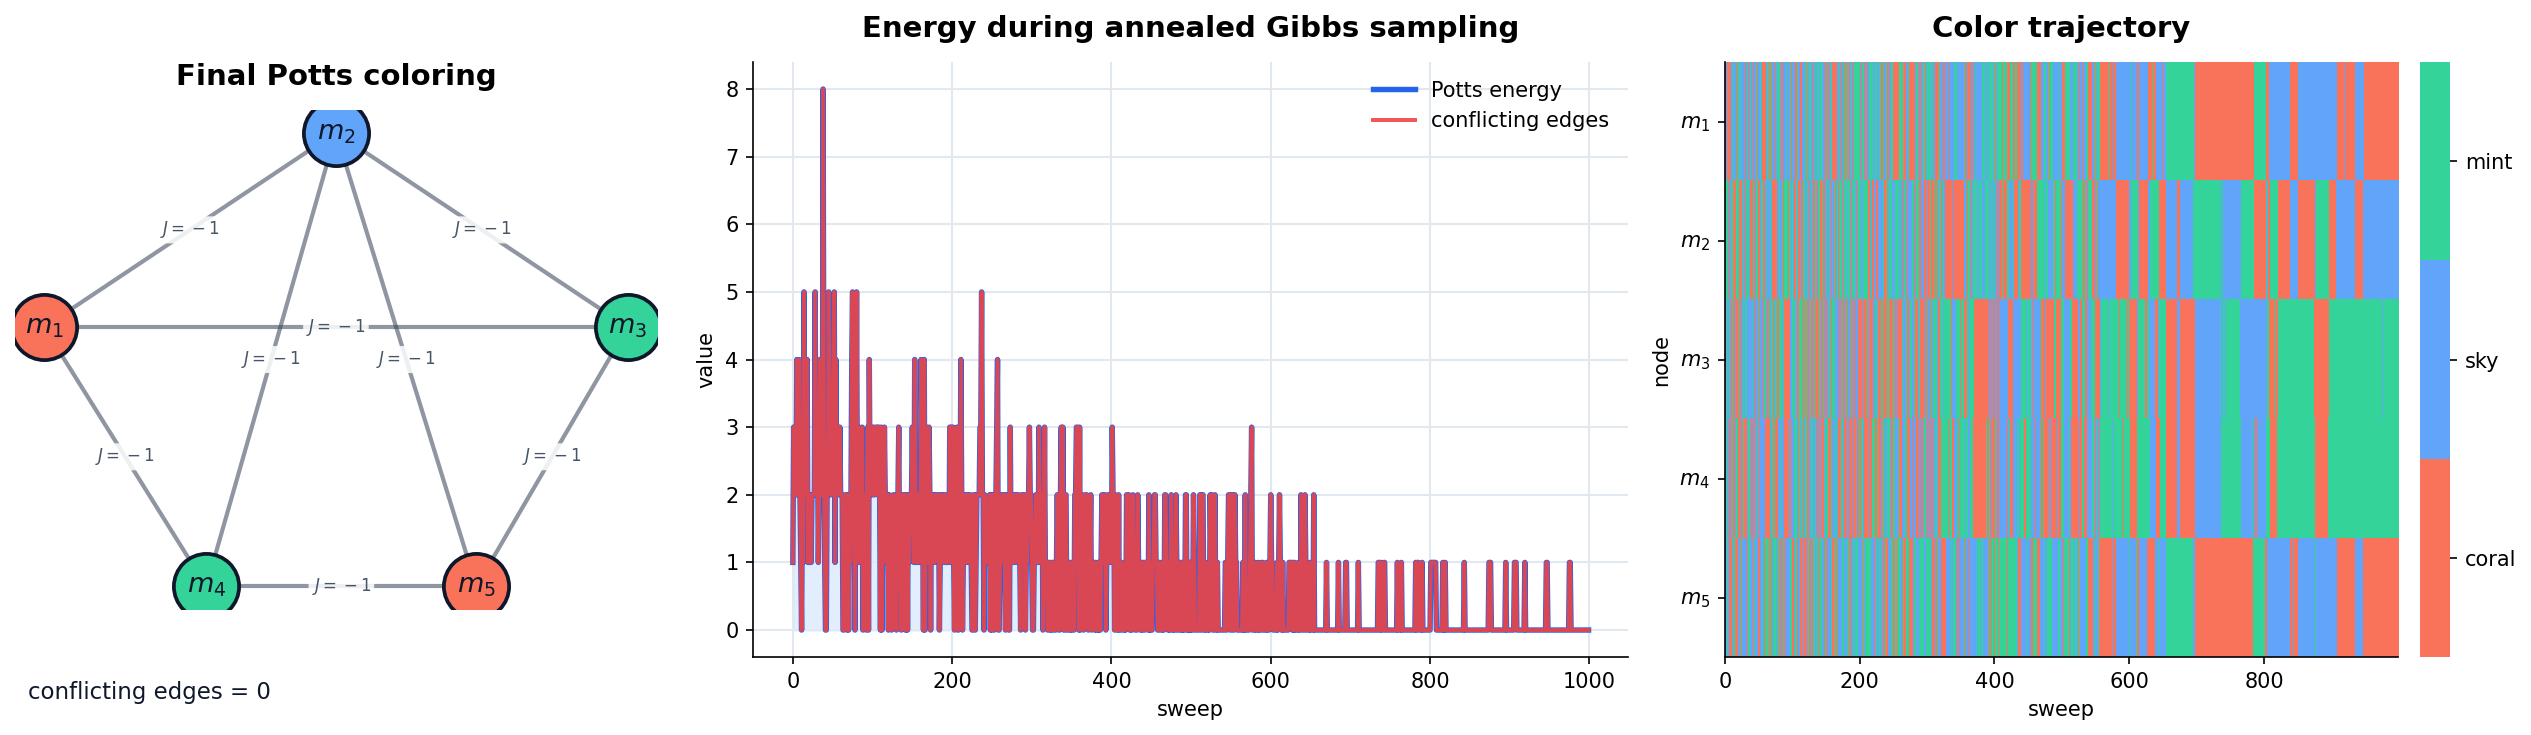

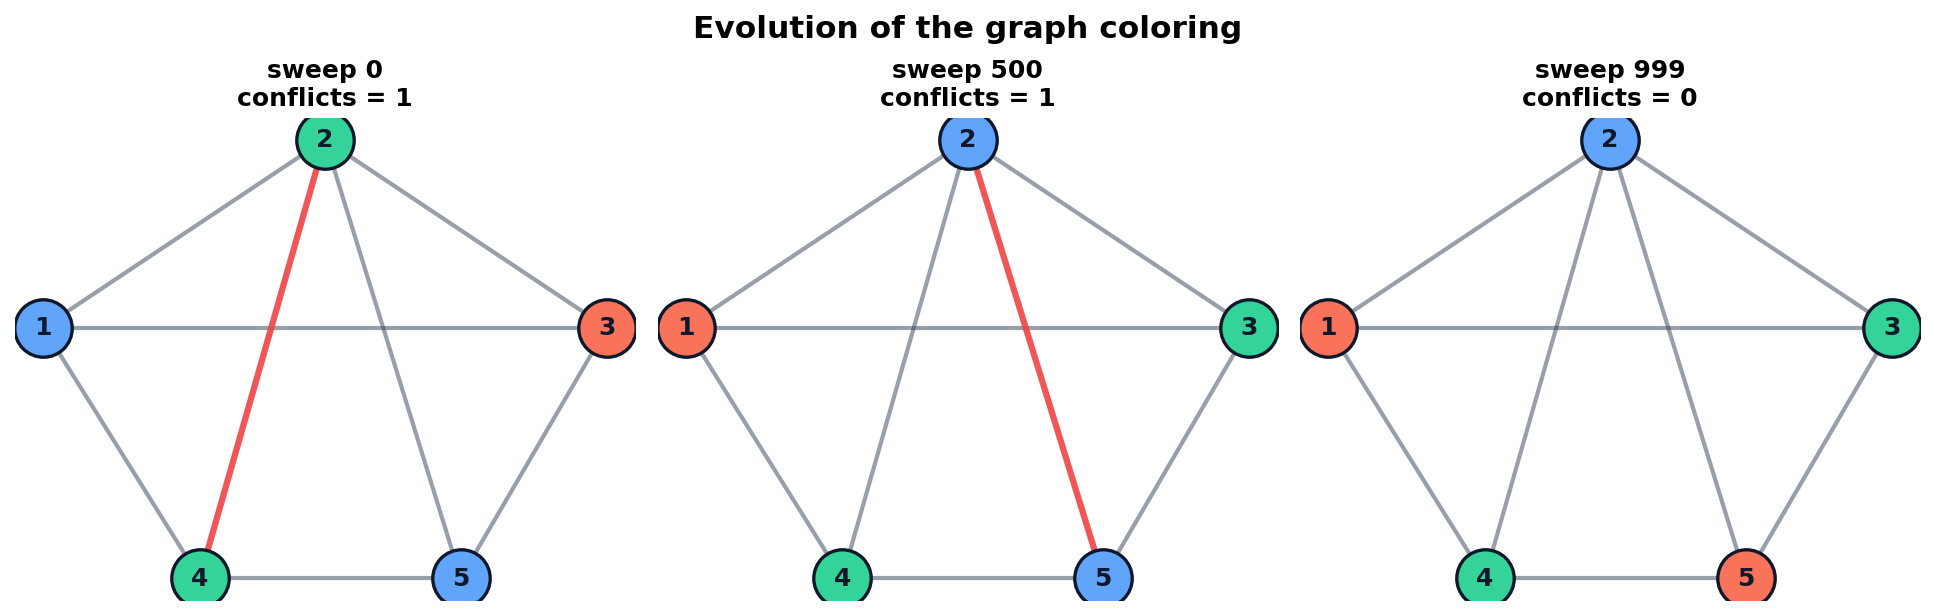

In [9]:
############################# Beautiful diagnostics and final coloring ####################

plot_states = all_states.astype(int)
final_state = plot_states[-1]

node_positions = {
    1: np.array([0.0, 1.2]),
    2: np.array([1.35, 2.1]),
    3: np.array([2.7, 1.2]),
    4: np.array([0.75, 0.0]),
    5: np.array([2.0, 0.0]),
}

color_names = ['coral', 'sky', 'mint']
palette = np.array(['#f9735b', '#60a5fa', '#34d399'])

def count_conflicts(state):
    return sum(state[i - 1] == state[j - 1] for i, j in Edges)

conflicts = np.array([count_conflicts(s) for s in plot_states])

fig, axes = plt.subplots(1, 3, figsize=(17, 5), dpi=150, gridspec_kw={'width_ratios': [1.1, 1.5, 1.25]})
fig.patch.set_facecolor('white')

# Final graph coloring
ax = axes[0]
ax.set_title('Final Potts coloring', fontsize=14, weight='bold', pad=12)
for i, j in Edges:
    p_i, p_j = node_positions[i], node_positions[j]
    conflict = final_state[i - 1] == final_state[j - 1]
    ax.plot([p_i[0], p_j[0]], [p_i[1], p_j[1]], color='#ef4444' if conflict else '#334155', lw=3 if conflict else 2, alpha=0.9 if conflict else 0.55)
    midpoint = 0.5 * (p_i + p_j)
    ax.text(midpoint[0], midpoint[1], '$J=-1$', ha='center', va='center', fontsize=8, color='#475569', bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.85))

for node, xy in node_positions.items():
    color = palette[final_state[node - 1]]
    ax.scatter(xy[0], xy[1], s=980, color=color, edgecolor='#0f172a', linewidth=1.8, zorder=3)
    ax.text(xy[0], xy[1], f'$m_{node}$', ha='center', va='center', fontsize=13, weight='bold', color='#0f172a', zorder=4)

ax.text(0.02, -0.18, f'conflicting edges = {conflicts[-1]}', transform=ax.transAxes, fontsize=11, color='#0f172a')
ax.set_aspect('equal')
ax.axis('off')

# Energy and conflicts over sweeps
ax = axes[1]
x = np.arange(num_sweeps)
ax.plot(x, energy, color='#2563eb', lw=2.6, label='Potts energy')
ax.fill_between(x, energy, energy.min(), color='#bfdbfe', alpha=0.45)
ax.plot(x, conflicts, color='#ef4444', lw=1.9, alpha=0.9, label='conflicting edges')
ax.set_title('Energy during annealed Gibbs sampling', fontsize=14, weight='bold', pad=12)
ax.set_xlabel('sweep')
ax.set_ylabel('value')
ax.grid(True, color='#e2e8f0', linewidth=1)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, loc='upper right')

# Node-color trajectory
ax = axes[2]
cmap = plt.matplotlib.colors.ListedColormap(palette)
im = ax.imshow(plot_states.T, aspect='auto', interpolation='nearest', cmap=cmap, vmin=-0.5, vmax=num_colors - 0.5)
ax.set_title('Color trajectory', fontsize=14, weight='bold', pad=12)
ax.set_xlabel('sweep')
ax.set_ylabel('node')
ax.set_yticks(np.arange(num_spins))
ax.set_yticklabels([f'$m_{i+1}$' for i in range(num_spins)])
ax.spines[['top', 'right']].set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03, ticks=np.arange(num_colors))
cbar.ax.set_yticklabels(color_names)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

snapshot_sweeps = [0, num_sweeps // 2, num_sweeps - 1]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), dpi=150)
fig.patch.set_facecolor('white')

for ax, sweep in zip(axes, snapshot_sweeps):
    state_snapshot = plot_states[sweep]
    for i, j in Edges:
        p_i, p_j = node_positions[i], node_positions[j]
        conflict = state_snapshot[i - 1] == state_snapshot[j - 1]
        ax.plot([p_i[0], p_j[0]], [p_i[1], p_j[1]], color='#ef4444' if conflict else '#334155', lw=3 if conflict else 2, alpha=0.9 if conflict else 0.5)
    for node, xy in node_positions.items():
        ax.scatter(xy[0], xy[1], s=760, color=palette[state_snapshot[node - 1]], edgecolor='#0f172a', linewidth=1.6, zorder=3)
        ax.text(xy[0], xy[1], f'{node}', ha='center', va='center', fontsize=12, weight='bold', color='#0f172a', zorder=4)
    ax.set_title(f'sweep {sweep}\nconflicts = {count_conflicts(state_snapshot)}', fontsize=12, weight='bold')
    ax.set_aspect('equal')
    ax.axis('off')

plt.suptitle('Evolution of the graph coloring', fontsize=15, weight='bold', y=1.03)
plt.tight_layout()
plt.show()
